# Chapter 6 - Ensemble Models - Homework

## Dataset: Students Performance in 2024 JAMB

Goal: Create a regression model to predict `jamb_score`

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(1)

## Download and Load Dataset

In [2]:
# Download the dataset
# Caricamento del dataset
url = 'https://github.com/alexeygrigorev/datasets/raw/refs/heads/master/jamb_exam_results.csv'
response = requests.get(url)
open("jamb_exam_results.csv", "wb").write(response.content)


391501

In [3]:
# Load the dataset
df = pd.read_csv('jamb_exam_results.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5000, 17)


,JAMB_Score,Study_Hours_Per_Week,Attendance_Rate,Teacher_Quality,Distance_To_School,School_Type,School_Location,Extra_Tutorials,Access_To_Learning_Materials,Parent_Involvement,IT_Knowledge,Student_ID,Age,Gender,Socioeconomic_Status,Parent_Education_Level,Assignments_Completed
0,192,22,78,4,12.4,Public,Urban,Yes,Yes,High,Medium,1,17,Male,Low,Tertiary,2
1,207,14,88,4,2.7,Public,Rural,No,Yes,High,High,2,15,Male,High,NaN,1
2,182,29,87,2,9.6,Public,Rural,Yes,Yes,High,Medium,3,20,Female,High,Tertiary,2
3,210,29,99,2,2.6,Public,Urban,No,Yes,Medium,High,4,22,Female,Medium,Tertiary,1
4,199,12,98,3,8.8,Public,Urban,No,Yes,Medium,Medium,5,22,Female,Medium,Tertiary,1


## Data Preparation

In [4]:
# Make column names lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

print("Columns after normalization:")
print(df.columns.tolist())

Columns after normalization:
['jamb_score', 'study_hours_per_week', 'attendance_rate', 'teacher_quality', 'distance_to_school', 'school_type', 'school_location', 'extra_tutorials', 'access_to_learning_materials', 'parent_involvement', 'it_knowledge', 'student_id', 'age', 'gender', 'socioeconomic_status', 'parent_education_level', 'assignments_completed']


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Missing values per column:
jamb_score                        0
study_hours_per_week              0
attendance_rate                   0
teacher_quality                   0
distance_to_school                0
school_type                       0
school_location                   0
extra_tutorials                   0
access_to_learning_materials      0
parent_involvement                0
it_knowledge                      0
student_id                        0
age                               0
gender                            0
socioeconomic_status              0
parent_education_level          891
assignments_completed             0
dtype: int64

Data types:
jamb_score                        int64
study_hours_per_week              int64
attendance_rate                   int64
teacher_quality                   int64
distance_to_school              float64
school_type                      object
school_location                  object
extra_tutorials                  object
access_to_learn

In [6]:
# Remove student_id column
if 'student_id' in df.columns:
    df = df.drop('student_id', axis=1)
    print("Removed 'student_id' column")

# Fill missing values with zeros
df = df.fillna(0)

print(f"\nDataset shape after preparation: {df.shape}")
print(f"Missing values after filling: {df.isnull().sum().sum()}")

Removed 'student_id' column

Dataset shape after preparation: (5000, 16)
Missing values after filling: 0


In [7]:
# Train/Validation/Test split (60%/20%/20%)

# First split: 60% train, 40% temp (validation + test)
df_train_full, df_temp = train_test_split(df, test_size=0.4, random_state=1)

# Second split: split temp 50/50 to get 20% validation and 20% test
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=1)

print(f"Train set size: {len(df_train_full)} ({len(df_train_full)/len(df)*100:.1f}%)")
print(f"Validation set size: {len(df_val)} ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test set size: {len(df_test)} ({len(df_test)/len(df)*100:.1f}%)")

Train set size: 3000 (60.0%)
Validation set size: 1000 (20.0%)
Test set size: 1000 (20.0%)


In [8]:
# Separate target variable from features
y_train = df_train_full['jamb_score'].values
y_val = df_val['jamb_score'].values
y_test = df_test['jamb_score'].values

# Remove target from features
df_train_full = df_train_full.drop('jamb_score', axis=1)
df_val = df_val.drop('jamb_score', axis=1)
df_test = df_test.drop('jamb_score', axis=1)

print(f"Features: {df_train_full.columns.tolist()}")
print(f"\nTarget shape - Train: {y_train.shape}, Val: {y_val.shape}, Test: {y_test.shape}")

Features: ['study_hours_per_week', 'attendance_rate', 'teacher_quality', 'distance_to_school', 'school_type', 'school_location', 'extra_tutorials', 'access_to_learning_materials', 'parent_involvement', 'it_knowledge', 'age', 'gender', 'socioeconomic_status', 'parent_education_level', 'assignments_completed']

Target shape - Train: (3000,), Val: (1000,), Test: (1000,)


In [9]:
# Convert DataFrames to dictionaries for DictVectorizer
train_dicts = df_train_full.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')
test_dicts = df_test.to_dict(orient='records')

# Apply DictVectorizer with sparse=True
dv = DictVectorizer(sparse=True)

X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)
X_test = dv.transform(test_dicts)

print(f"Feature matrix shape - Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"\nFeature names ({len(dv.feature_names_)}): {dv.feature_names_}")

Feature matrix shape - Train: (3000, 29), Val: (1000, 29), Test: (1000, 29)

Feature names (29): ['access_to_learning_materials=No', 'access_to_learning_materials=Yes', 'age', 'assignments_completed', 'attendance_rate', 'distance_to_school', 'extra_tutorials=No', 'extra_tutorials=Yes', 'gender=Female', 'gender=Male', 'it_knowledge=High', 'it_knowledge=Low', 'it_knowledge=Medium', 'parent_education_level', 'parent_education_level=Primary', 'parent_education_level=Secondary', 'parent_education_level=Tertiary', 'parent_involvement=High', 'parent_involvement=Low', 'parent_involvement=Medium', 'school_location=Rural', 'school_location=Urban', 'school_type=Private', 'school_type=Public', 'socioeconomic_status=High', 'socioeconomic_status=Low', 'socioeconomic_status=Medium', 'study_hours_per_week', 'teacher_quality']


## Question 1: Decision Tree - Split Feature

Train a decision tree regressor with `max_depth=1` and identify which feature is used for splitting.

In [10]:
# Train decision tree with max_depth=1
dt = DecisionTreeRegressor(max_depth=1, random_state=1)
dt.fit(X_train, y_train)

# Get the feature used for splitting
feature_idx = dt.tree_.feature[0]
split_feature = dv.feature_names_[feature_idx]

print(f"Feature used for splitting: {split_feature}")

# Also show the feature importance
print("\nFeature importances:")
for feat, imp in zip(dv.feature_names_, dt.feature_importances_):
    if imp > 0:
        print(f"  {feat}: {imp:.4f}")

Feature used for splitting: study_hours_per_week

Feature importances:
  study_hours_per_week: 1.0000


In [11]:
# Calculate RMSE for this model
y_pred = dt.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE with max_depth=1: {rmse:.2f}")

RMSE with max_depth=1: 44.86


### Answer Q1:
The feature used for splitting is displayed above.

## Question 2: Random Forest RMSE

Train a random forest regressor with `n_estimators=10`, `random_state=1`, and calculate RMSE on validation data.

In [12]:
# Train Random Forest
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict on validation set
y_pred = rf.predict(X_val)

# Calculate RMSE
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE (Random Forest, n_estimators=10): {rmse_rf:.2f}")

RMSE (Random Forest, n_estimators=10): 43.16


### Answer Q2:
RMSE is displayed above. Compare with options: 22.13, 42.13, 62.13, 82.12

## Question 3: Optimal n_estimators

Experiment with `n_estimators` from 10 to 200 (step 10) and find when RMSE stops improving.

In [13]:
# Test different values of n_estimators
n_estimators_range = range(10, 201, 10)
rmse_scores = []

for n in n_estimators_range:
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)
    print(f"n_estimators={n:3d}: RMSE={rmse:.3f}")

# Store results in a dataframe
results_df = pd.DataFrame({
    'n_estimators': list(n_estimators_range),
    'rmse': rmse_scores
})

print("\n" + "="*50)
print(results_df.to_string(index=False))

n_estimators= 10: RMSE=43.158
n_estimators= 20: RMSE=41.790
n_estimators= 30: RMSE=41.556
n_estimators= 40: RMSE=41.076
n_estimators= 50: RMSE=40.957
n_estimators= 60: RMSE=40.774
n_estimators= 70: RMSE=40.588
n_estimators= 80: RMSE=40.503
n_estimators= 90: RMSE=40.435
n_estimators=100: RMSE=40.365
n_estimators=110: RMSE=40.348
n_estimators=120: RMSE=40.302
n_estimators=130: RMSE=40.286
n_estimators=140: RMSE=40.263
n_estimators=150: RMSE=40.254
n_estimators=160: RMSE=40.200
n_estimators=170: RMSE=40.187
n_estimators=180: RMSE=40.136
n_estimators=190: RMSE=40.152
n_estimators=200: RMSE=40.138

 n_estimators      rmse
           10 43.157759
           20 41.790440
           30 41.555818
           40 41.075632
           50 40.957157
           60 40.773685
           70 40.587806
           80 40.502704
           90 40.434922
          100 40.364910
          110 40.347525
          120 40.301918
          130 40.285789
          140 40.263461
          150 40.254264
          160 4

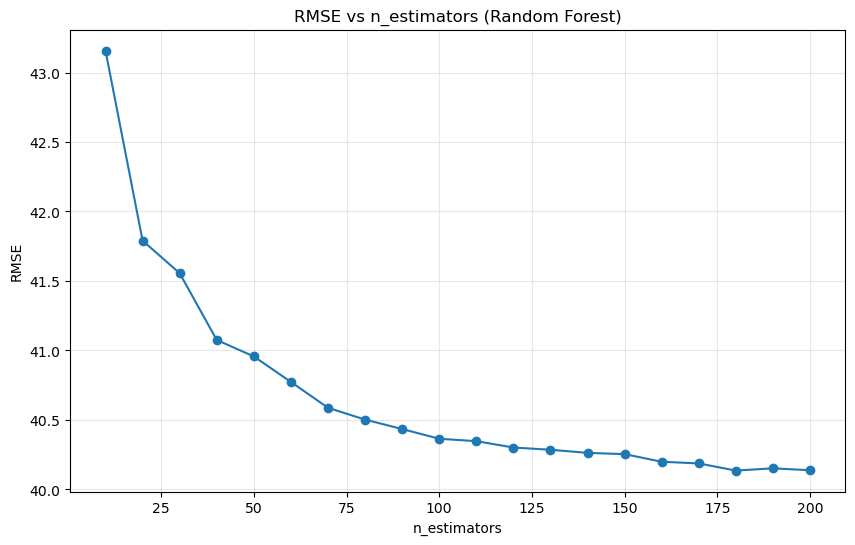

In [14]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, rmse_scores, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('RMSE vs n_estimators (Random Forest)')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Find when RMSE stops improving (considering 3 decimal places)
# Find the point where improvement becomes minimal
min_rmse = min(rmse_scores)
min_idx = rmse_scores.index(min_rmse)
optimal_n_estimators = list(n_estimators_range)[min_idx]

print(f"Minimum RMSE: {min_rmse:.3f}")
print(f"Achieved at n_estimators: {optimal_n_estimators}")

# Check when RMSE stops improving significantly (difference < 0.001)
print("\nAnalyzing improvement:")
for i in range(1, len(rmse_scores)):
    improvement = rmse_scores[i-1] - rmse_scores[i]
    n_est = list(n_estimators_range)[i]
    print(f"n={n_est}: improvement={improvement:.3f}")
    if abs(improvement) < 0.001:
        print(f"\nRMSE stops improving significantly after n_estimators={n_est}")
        break

Minimum RMSE: 40.136
Achieved at n_estimators: 180

Analyzing improvement:
n=20: improvement=1.367
n=30: improvement=0.235
n=40: improvement=0.480
n=50: improvement=0.118
n=60: improvement=0.183
n=70: improvement=0.186
n=80: improvement=0.085
n=90: improvement=0.068
n=100: improvement=0.070
n=110: improvement=0.017
n=120: improvement=0.046
n=130: improvement=0.016
n=140: improvement=0.022
n=150: improvement=0.009
n=160: improvement=0.055
n=170: improvement=0.012
n=180: improvement=0.051
n=190: improvement=-0.016
n=200: improvement=0.014


### Answer Q3:
Based on the analysis above (3 decimal places), RMSE stops improving after the n_estimators value shown.

Options: 10, 25, 80, 200

## Question 4: Best max_depth

Select the best `max_depth` by trying values [10, 15, 20, 25] and for each, varying `n_estimators` from 10 to 200 (step 10).

In [16]:
# Test different max_depth values
max_depth_values = [10, 15, 20, 25]
n_estimators_range = range(10, 201, 10)

results = []

for max_depth in max_depth_values:
    print(f"\nTesting max_depth={max_depth}")
    depth_rmse_scores = []
    
    for n in n_estimators_range:
        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=max_depth,
            random_state=1,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        depth_rmse_scores.append(rmse)
    
    mean_rmse = np.mean(depth_rmse_scores)
    results.append({
        'max_depth': max_depth,
        'mean_rmse': mean_rmse,
        'min_rmse': min(depth_rmse_scores),
        'max_rmse': max(depth_rmse_scores),
        'rmse_scores': depth_rmse_scores
    })
    
    print(f"  Mean RMSE: {mean_rmse:.3f}")
    print(f"  Min RMSE:  {min(depth_rmse_scores):.3f}")
    print(f"  Max RMSE:  {max(depth_rmse_scores):.3f}")


Testing max_depth=10
  Mean RMSE: 40.138
  Min RMSE:  39.823
  Max RMSE:  41.645

Testing max_depth=15
  Mean RMSE: 40.644
  Min RMSE:  40.119
  Max RMSE:  42.869

Testing max_depth=20
  Mean RMSE: 40.610
  Min RMSE:  40.123
  Max RMSE:  42.930

Testing max_depth=25
  Mean RMSE: 40.688
  Min RMSE:  40.151
  Max RMSE:  43.158


In [17]:
# Summary of results
print("\n" + "="*60)
print("SUMMARY: Mean RMSE by max_depth")
print("="*60)

summary_df = pd.DataFrame([{
    'max_depth': r['max_depth'],
    'mean_rmse': r['mean_rmse']
} for r in results])

print(summary_df.to_string(index=False))

# Find best max_depth
best_result = min(results, key=lambda x: x['mean_rmse'])
print(f"\nBest max_depth: {best_result['max_depth']} (mean RMSE: {best_result['mean_rmse']:.3f})")


SUMMARY: Mean RMSE by max_depth
 max_depth  mean_rmse
        10  40.138004
        15  40.643966
        20  40.609820
        25  40.687582

Best max_depth: 10 (mean RMSE: 40.138)


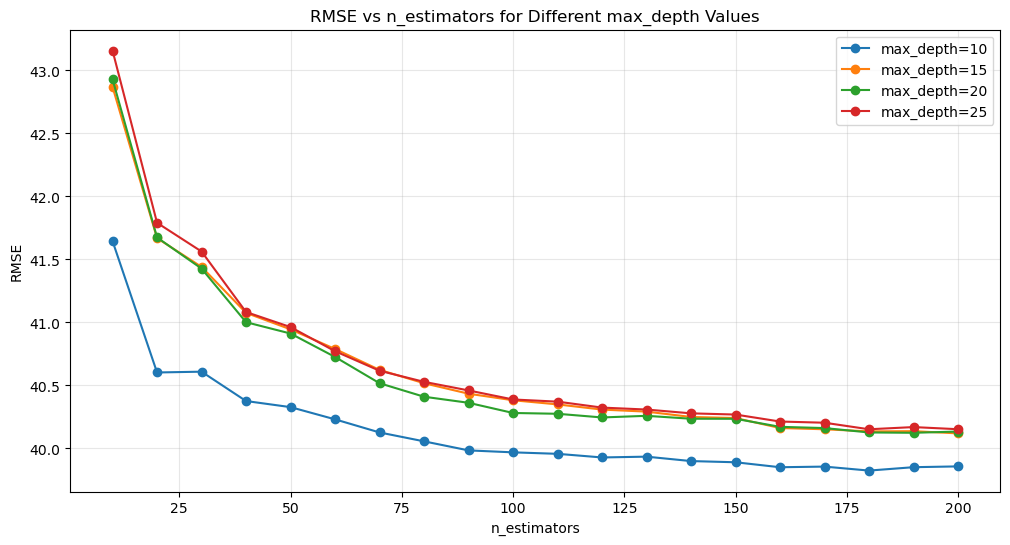

In [18]:
# Plot RMSE for different max_depth values
plt.figure(figsize=(12, 6))

for result in results:
    plt.plot(n_estimators_range, result['rmse_scores'], 
             marker='o', label=f"max_depth={result['max_depth']}")

plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('RMSE vs n_estimators for Different max_depth Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Answer Q4:
The best max_depth based on mean RMSE is displayed above.

Options: 10, 15, 20, 25

## Question 5: Feature Importance

Train a model with `n_estimators=10`, `max_depth=20`, `random_state=1` and find the most important feature.

In [19]:
# Train Random Forest with specified parameters
rf_importance = RandomForestRegressor(
    n_estimators=10,
    max_depth=20,
    random_state=1,
    n_jobs=-1
)
rf_importance.fit(X_train, y_train)

# Get feature importances
feature_importances = rf_importance.feature_importances_

# Create a dataframe with feature names and importances
importance_df = pd.DataFrame({
    'feature': dv.feature_names_,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print("Feature Importances (sorted):")
print("="*60)
print(importance_df.to_string(index=False))

print(f"\n\nMost important feature: {importance_df.iloc[0]['feature']}")
print(f"Importance score: {importance_df.iloc[0]['importance']:.4f}")

Feature Importances (sorted):
                         feature  importance
            study_hours_per_week    0.254075
                 attendance_rate    0.152135
              distance_to_school    0.135761
                 teacher_quality    0.081733
                             age    0.064395
           assignments_completed    0.034429
         parent_involvement=High    0.025249
       socioeconomic_status=High    0.018695
               it_knowledge=High    0.016275
          parent_involvement=Low    0.016064
parent_education_level=Secondary    0.014632
 parent_education_level=Tertiary    0.014306
        socioeconomic_status=Low    0.013721
                it_knowledge=Low    0.013349
     socioeconomic_status=Medium    0.012501
  parent_education_level=Primary    0.012056
             it_knowledge=Medium    0.011727
              extra_tutorials=No    0.011601
       parent_involvement=Medium    0.011180
             extra_tutorials=Yes    0.010880
                     gend

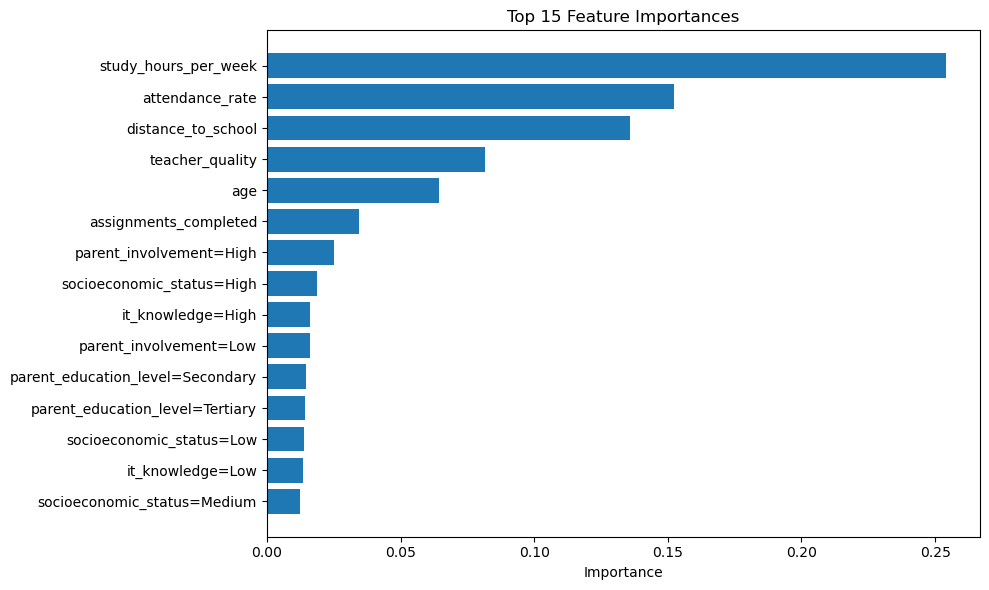

In [20]:
# Visualize top features
plt.figure(figsize=(10, 6))
top_n = min(15, len(importance_df))  # Show top 15 features or all if less
top_features = importance_df.head(top_n)

plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [21]:
# Focus on the 4 features mentioned in the question
target_features = ['study_hours_per_week', 'attendance_rate', 'distance_to_school', 'teacher_quality']

print("\nImportance of the 4 key features:")
print("="*60)

for feat in target_features:
    if feat in importance_df['feature'].values:
        imp = importance_df[importance_df['feature'] == feat]['importance'].values[0]
        print(f"{feat:30s}: {imp:.4f}")
    else:
        print(f"{feat:30s}: Feature not found")

# Find most important among these 4
target_importance_df = importance_df[importance_df['feature'].isin(target_features)].sort_values('importance', ascending=False)
if not target_importance_df.empty:
    print(f"\nMost important among the 4: {target_importance_df.iloc[0]['feature']}")


Importance of the 4 key features:
study_hours_per_week          : 0.2541
attendance_rate               : 0.1521
distance_to_school            : 0.1358
teacher_quality               : 0.0817

Most important among the 4: study_hours_per_week


### Answer Q5:
The most important feature among the 4 options is displayed above.

Options: study_hours_per_week, attendance_rate, distance_to_school, teacher_quality

## Question 6: XGBoost eta Tuning

Train XGBoost models with different `eta` values (0.3 and 0.1) and compare RMSE.

In [22]:
# Install xgboost if needed
try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
except ImportError:
    print("Installing xgboost...")
    !pip install xgboost
    import xgboost as xgb
    print("XGBoost installed successfully. Version:", xgb.__version__)

Installing xgboost...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.3 MB/s  0:00:00
XGBoost installed successfully. Version: 3.1.1


In [23]:
# Create DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=dv.feature_names_)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=dv.feature_names_)

# Create watchlist to monitor training
watchlist = [(dtrain, 'train'), (dval, 'val')]

print("DMatrix created successfully")
print(f"Train shape: {dtrain.num_row()} x {dtrain.num_col()}")
print(f"Val shape: {dval.num_row()} x {dval.num_col()}")

DMatrix created successfully
Train shape: 3000 x 29
Val shape: 1000 x 29


### Training with eta=0.3

In [24]:
# XGBoost parameters with eta=0.3
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

print("Training XGBoost with eta=0.3")
print("="*60)

model_eta_03 = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=100,
    evals=watchlist,
    verbose_eval=10
)

Training XGBoost with eta=0.3
[0]	train-rmse:42.84835	val-rmse:44.52338
[10]	train-rmse:31.73818	val-rmse:40.83759
[20]	train-rmse:27.52551	val-rmse:41.28381
[30]	train-rmse:25.19051	val-rmse:41.61678
[40]	train-rmse:22.21691	val-rmse:42.04865
[50]	train-rmse:19.90566	val-rmse:42.31672
[60]	train-rmse:17.78802	val-rmse:42.54742
[70]	train-rmse:16.24964	val-rmse:42.89325
[80]	train-rmse:14.65331	val-rmse:43.21506
[90]	train-rmse:13.37213	val-rmse:43.24201
[99]	train-rmse:12.29305	val-rmse:43.34291


In [25]:
# Predictions and RMSE for eta=0.3
y_pred_eta_03 = model_eta_03.predict(dval)
rmse_eta_03 = np.sqrt(mean_squared_error(y_val, y_pred_eta_03))

print(f"\nFinal RMSE (eta=0.3): {rmse_eta_03:.4f}")


Final RMSE (eta=0.3): 43.3429


### Training with eta=0.1

In [26]:
# XGBoost parameters with eta=0.1
xgb_params_01 = xgb_params.copy()
xgb_params_01['eta'] = 0.1

print("Training XGBoost with eta=0.1")
print("="*60)

model_eta_01 = xgb.train(
    xgb_params_01,
    dtrain,
    num_boost_round=100,
    evals=watchlist,
    verbose_eval=10
)

Training XGBoost with eta=0.1
[0]	train-rmse:45.64414	val-rmse:46.63724
[10]	train-rmse:37.26338	val-rmse:41.35829
[20]	train-rmse:33.94837	val-rmse:40.40272
[30]	train-rmse:31.97085	val-rmse:40.20269
[40]	train-rmse:30.48894	val-rmse:40.26732
[50]	train-rmse:29.42464	val-rmse:40.42217
[60]	train-rmse:28.40566	val-rmse:40.50575
[70]	train-rmse:27.14408	val-rmse:40.58776
[80]	train-rmse:26.19196	val-rmse:40.64646
[90]	train-rmse:25.38224	val-rmse:40.72848
[99]	train-rmse:24.58526	val-rmse:40.83188


In [27]:
# Predictions and RMSE for eta=0.1
y_pred_eta_01 = model_eta_01.predict(dval)
rmse_eta_01 = np.sqrt(mean_squared_error(y_val, y_pred_eta_01))

print(f"\nFinal RMSE (eta=0.1): {rmse_eta_01:.4f}")


Final RMSE (eta=0.1): 40.8319


### Comparison

In [28]:
# Compare results
print("\n" + "="*60)
print("XGBoost Results Comparison")
print("="*60)
print(f"eta=0.3: RMSE = {rmse_eta_03:.4f}")
print(f"eta=0.1: RMSE = {rmse_eta_01:.4f}")
print("="*60)

if rmse_eta_03 < rmse_eta_01:
    print("\nBest eta: 0.3")
    print(f"Improvement: {rmse_eta_01 - rmse_eta_03:.4f} (lower is better)")
elif rmse_eta_01 < rmse_eta_03:
    print("\nBest eta: 0.1")
    print(f"Improvement: {rmse_eta_03 - rmse_eta_01:.4f} (lower is better)")
else:
    print("\nBoth eta values give equal RMSE")


XGBoost Results Comparison
eta=0.3: RMSE = 43.3429
eta=0.1: RMSE = 40.8319

Best eta: 0.1
Improvement: 2.5110 (lower is better)


### Answer Q6:
The best eta value based on validation RMSE is displayed above.

Options: 0.3, 0.1, Both give equal value

## Summary of Answers

Run all cells above to get the answers to each question:

1. **Question 1**: Feature used for splitting in decision tree (max_depth=1)
2. **Question 2**: RMSE of Random Forest with n_estimators=10
3. **Question 3**: After which n_estimators does RMSE stop improving?
4. **Question 4**: Best max_depth based on mean RMSE
5. **Question 5**: Most important feature among the 4 options
6. **Question 6**: Best eta value (0.3 vs 0.1) for XGBoost

---

**Note**: Select the option closest to your solution if it doesn't match exactly. If it's exactly in between two options, select the higher value.